# Task 4
> - Implement K-Means from scratch and use the elbow method to pick a good value of k.


In [1]:
import numpy as np

X = np.array([
    [1, 2],
    [1, 3],
    [2, 2],
    [2, 3],
    [8, 8],
    [9, 8],
    [8, 9],
    [9, 9]
])

In [2]:
import numpy as np


def kmeans(X, k, max_iterations=100):

    # Randomly select initial centroids
    indices = np.random.choice(
        len(X),
        k,
        replace=False
    )

    centroids = X[indices]

    for _ in range(max_iterations):

        # Calculate distances
        distances = np.linalg.norm(
            X[:, np.newaxis] - centroids,
            axis=2
        )

        # Assign each point to nearest centroid
        labels = np.argmin(distances, axis=1)

        # Calculate new centroids
        new_centroids = np.array([
            X[labels == i].mean(axis=0)
            for i in range(k)
        ])

        # Stop if centroids don't change
        if np.allclose(centroids, new_centroids):
            break

        centroids = new_centroids

    return labels, centroids


labels, centroids = kmeans(X, k=2)

print("Labels:", labels)
print("Centroids:")
print(centroids)

Labels: [0 0 0 0 1 1 1 1]
Centroids:
[[1.5 2.5]
 [8.5 8.5]]


Elbow Method

The major question is:

How do we choose K?

The elbow method evaluates the within-cluster sum of squares (WCSS) / inertia.

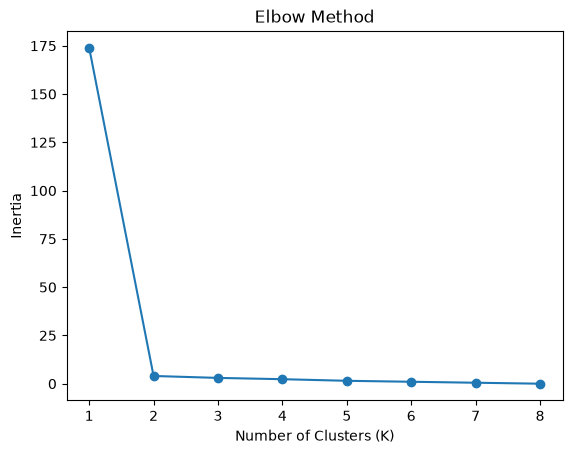

In [4]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []

for k in range(1, len(X) + 1):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X)

    inertias.append(model.inertia_)

plt.plot(range(1, len(X) + 1), inertias, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()